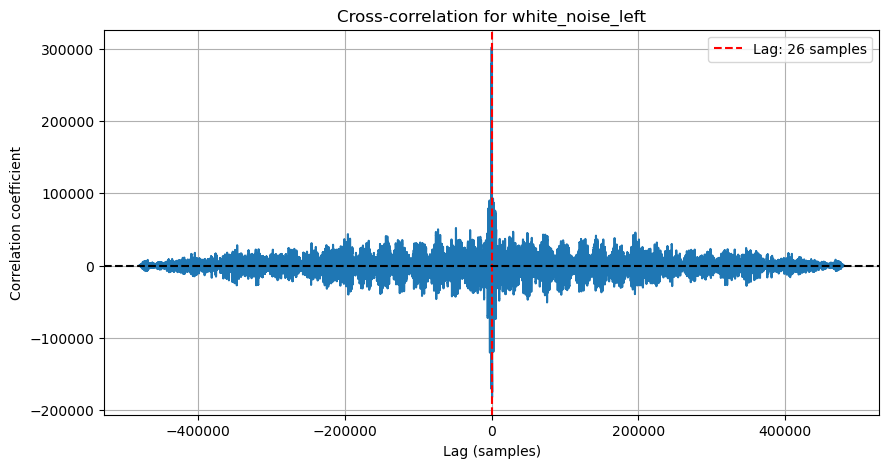

Fichier : white_noise_left
---------------------------------
Décalage : 26 échantillons (0.54 ms)


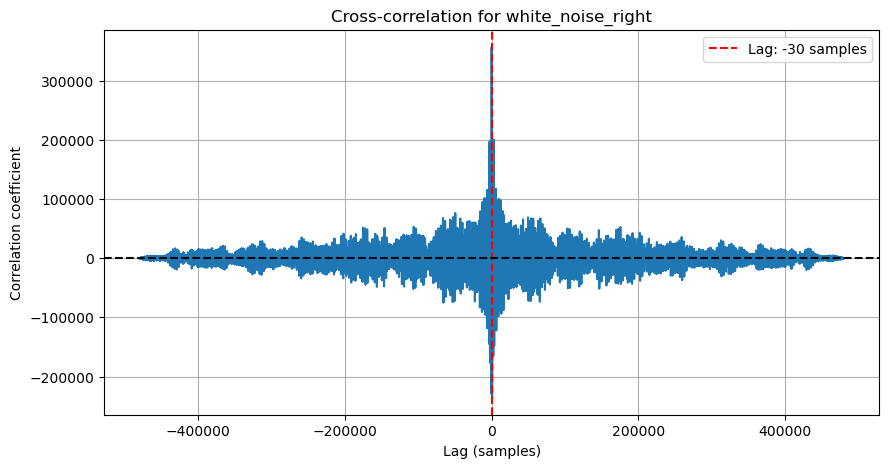

Fichier : white_noise_right
---------------------------------
Décalage : -30 échantillons (-0.62 ms)


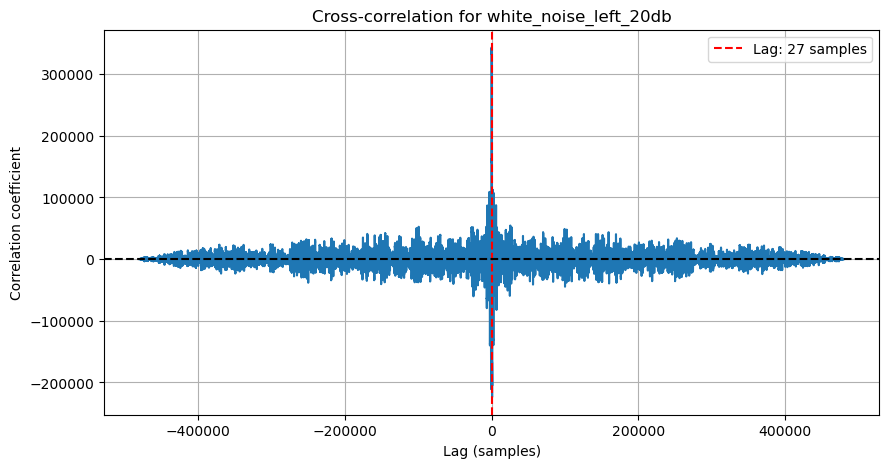

Fichier : white_noise_left_20db
---------------------------------
Décalage : 27 échantillons (0.56 ms)


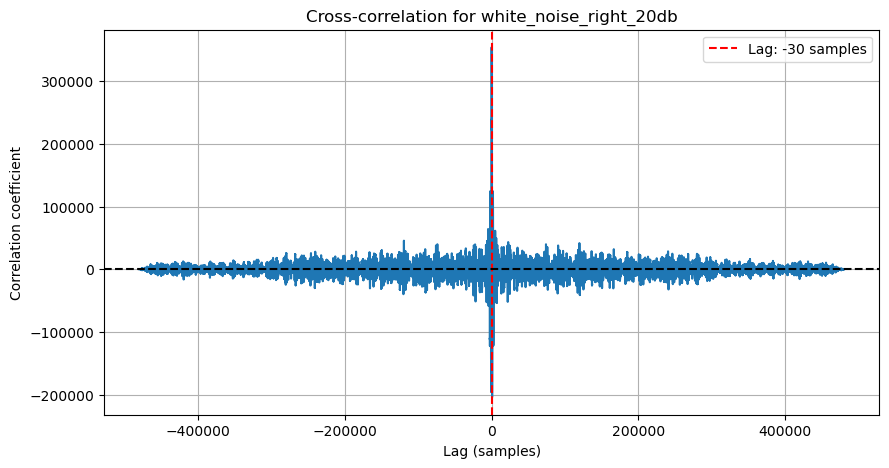

Fichier : white_noise_right_20db
---------------------------------
Décalage : -30 échantillons (-0.62 ms)


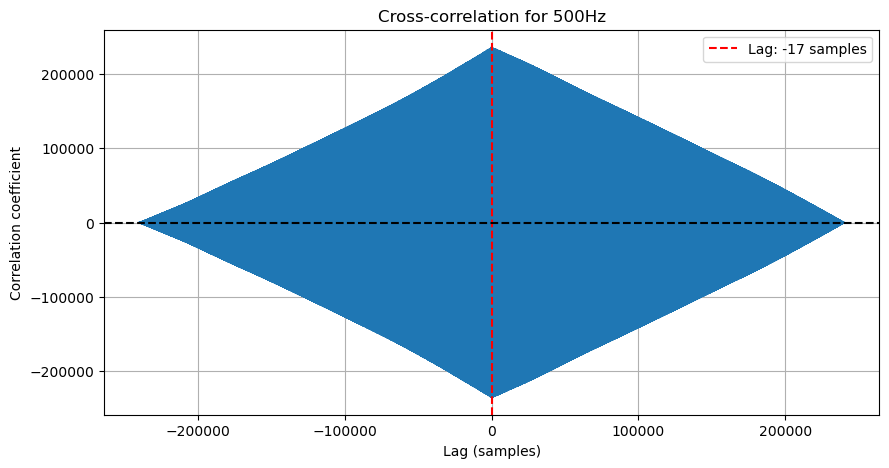

Fichier : 500Hz
---------------------------------
Décalage : -17 échantillons (-0.35 ms)
Résultats finaux :
Décalage moyen : (0.54 ms)


In [2]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
from scipy.signal import correlate

# === 1. Charger le fichier audio .wav ===
lag_samples = []
samples = ["white_noise_left", "white_noise_right", "white_noise_left_20db", "white_noise_right_20db", "500Hz"]
for sample in samples:
    sample_rate, stereo_data = wav.read(f"white_noise/{sample}.wav")

    # === 2. Extraire les canaux gauche et droit ===
    left_channel = stereo_data[:, 0]
    right_channel = stereo_data[:, 1]

    # === 3. (Optionnel) Normalisation
    def normalize(signal):
        return (signal - np.mean(signal)) / (np.std(signal) + 1e-10)

    left_channel = normalize(left_channel)
    right_channel = normalize(right_channel)

    # === 4. Cross-corrélation
    cross_corr = correlate(left_channel, right_channel, mode='full')
    lags = np.arange(-len(left_channel) + 1, len(left_channel))

    # === 5. Trouver le pic de corrélation
    max_corr_index = np.argmax(cross_corr)
    lag_in_samples = lags[max_corr_index]
    lag_in_ms = lag_in_samples / sample_rate * 1000  # conversion en ms
    plt.figure(figsize=(10, 5))
    plt.plot(lags, cross_corr)
    plt.title(f"Cross-correlation for {sample}")
    plt.xlabel("Lag (samples)")
    plt.ylabel("Correlation coefficient")
    plt.axvline(x=lag_in_samples, color='r', linestyle='--', label=f'Lag: {lag_in_samples} samples')
    plt.axhline(y=0, color='k', linestyle='--')
    plt.legend()
    plt.grid()
    plt.show()
    
    lag_samples.append(lag_in_ms)

    # === 7. Impression du décalage
    print(f"======================================")
    print(f"Fichier : {sample}")
    print("---------------------------------")
    print(f"Décalage : {lag_in_samples} échantillons ({lag_in_ms:.2f} ms)")
lag_tot = 0
for lag in lag_samples:
    lag_tot += np.abs(lag)
lag_tot /= len(lag_samples)
print("======================================")
print("Résultats finaux :")
print("======================================")
print(f"Décalage moyen : ({lag_tot:.2f} ms)")
